In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [47]:
url='https://raw.githubusercontent.com/VolatilityVoyage-FAC-SummerProject-2025/introduction-to-algo-trading-hk-365/refs/heads/main/data-27.csv?token=GHSAT0AAAAAADDX5KP2GD4Y2RJH6TSQOS5I2BGD7GQ'
df=pd.read_csv(url)

In [48]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2924 entries, 0 to 2923
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datetime      2924 non-null   object 
 1   open          2924 non-null   float64
 2   high          2924 non-null   float64
 3   low           2924 non-null   float64
 4   close         2924 non-null   float64
 5   volume        2924 non-null   float64
 6   Unnamed: 0.1  2193 non-null   float64
 7   Unnamed: 0    2193 non-null   float64
dtypes: float64(7), object(1)
memory usage: 182.9+ KB


,open,high,low,close,volume,Unnamed: 0.1,Unnamed: 0
count,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2193.000000,2193.000000
mean,18155.724839,18623.465082,17641.735393,18163.987353,67925.306605,1096.000000,1096.000000
std,15226.458730,15623.722788,14779.220733,15235.053085,76479.022079,633.208891,633.208891
min,3183.900000,3281.870000,3156.260000,3182.730000,3367.160695,0.000000,0.000000
25%,7202.790000,7408.750000,7017.480000,7202.960000,30075.857572,548.000000,548.000000
50%,10191.480000,10445.000000,9890.000000,10186.600000,43493.845601,1096.000000,1096.000000
75%,27272.127500,27817.137500,26812.465000,27321.242500,69989.787196,1644.000000,1644.000000
max,67525.820000,69000.000000,66222.400000,67525.830000,760705.362783,2192.000000,2192.000000


In [49]:
#basic EDA
print(df.isnull().sum())

datetime          0
open              0
high              0
low               0
close             0
volume            0
Unnamed: 0.1    731
Unnamed: 0      731
dtype: int64


In [50]:
df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], inplace=True)

In [51]:
df.head()

,datetime,open,high,low,close,volume
0,2018-01-01 00:00:00,13715.65,13818.55,12750.00,13135.00,6970.441076
1,2018-01-02 00:00:00,13135.00,14750.00,12890.02,14580.00,16359.347340
2,2018-01-03 00:00:00,14576.87,15473.49,14150.00,14749.97,19457.238601
3,2018-01-04 00:00:00,14710.00,15280.00,13918.04,14811.00,18783.876561
4,2018-01-05 00:00:00,14805.01,17118.13,14600.00,16579.00,22383.657333


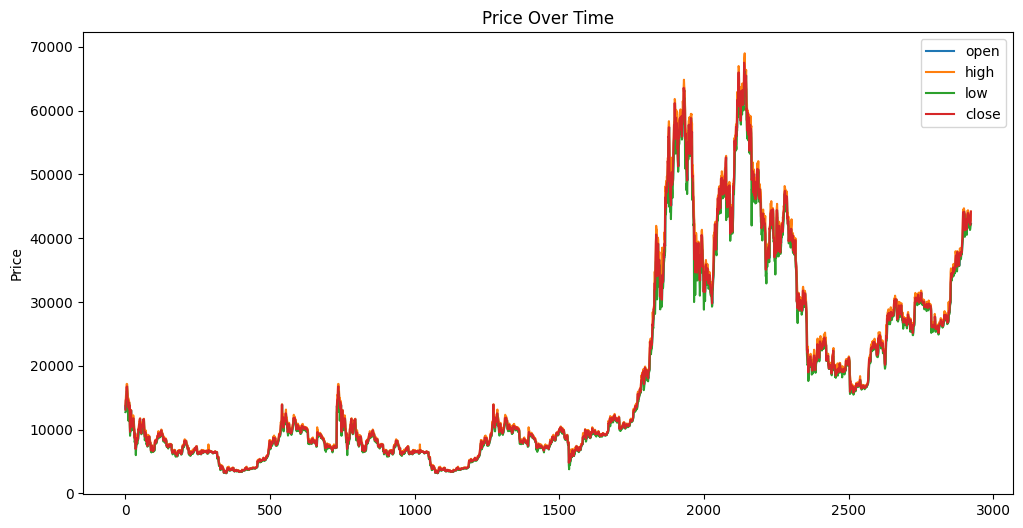

In [52]:
df[['open', 'high', 'low', 'close']].plot(figsize=(12,6))
plt.title('Price Over Time')
plt.ylabel('Price')
plt.show()

In [53]:
#calculating SMA and EMA using closing prices
df['SMA'] = df['close'].rolling(window=5).mean() #SMA over 5 days
df['EMA_20'] = df['close'].ewm(span=20,adjust=False).mean()
df['EMA_50'] = df['close'].ewm(span=50,adjust=False).mean()
df.head()

,datetime,open,high,low,close,volume,SMA,EMA_20,EMA_50
0,2018-01-01 00:00:00,13715.65,13818.55,12750.00,13135.00,6970.441076,NaN,13135.000000,13135.000000
1,2018-01-02 00:00:00,13135.00,14750.00,12890.02,14580.00,16359.347340,NaN,13272.619048,13191.666667
2,2018-01-03 00:00:00,14576.87,15473.49,14150.00,14749.97,19457.238601,NaN,13413.319138,13252.776601
3,2018-01-04 00:00:00,14710.00,15280.00,13918.04,14811.00,18783.876561,NaN,13546.431601,13313.883401
4,2018-01-05 00:00:00,14805.01,17118.13,14600.00,16579.00,22383.657333,14770.994,13835.247639,13441.927189


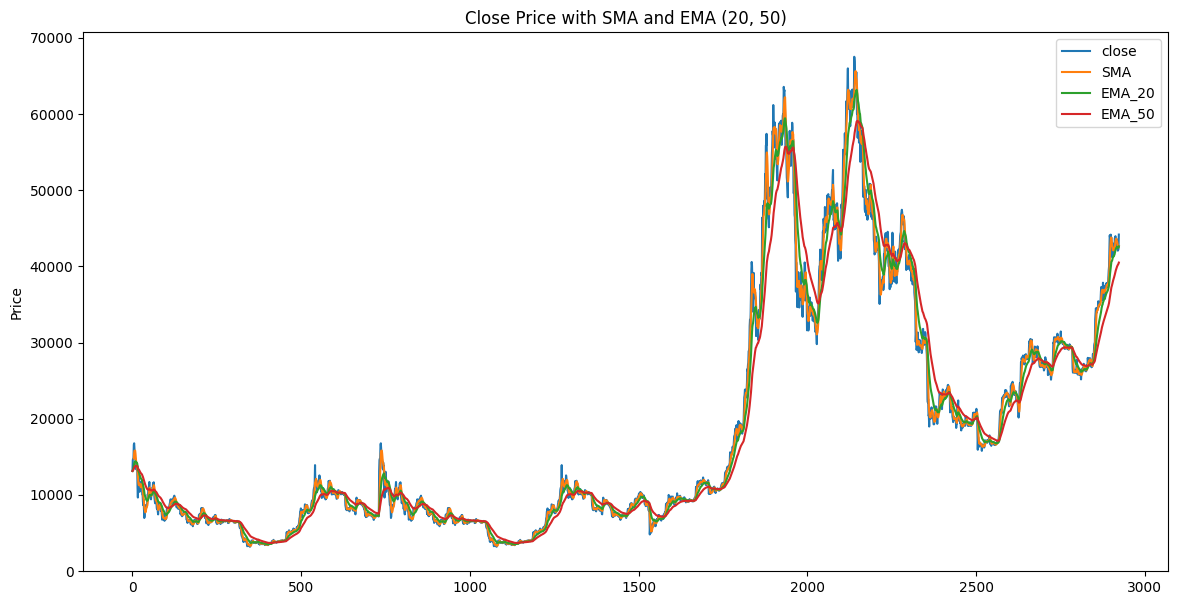

In [54]:
df[['close', 'SMA', 'EMA_20', 'EMA_50']].plot(figsize=(14,7))
plt.title('Close Price with SMA and EMA (20, 50)')
plt.ylabel('Price')
plt.show()

In [55]:
#calculating standard deviation over each 6 month period.

#cConverting 'datetime' to datetime type and set as index
df[df.columns[0]] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

std_6m = df['close'].resample('6ME').std()
#finding the most volatile (highest standard deviation) period
max_std_value = std_6m.max()
max_std_period = std_6m.idxmax()
start_date = (max_std_period - pd.DateOffset(months=6)) + pd.DateOffset(days=1)

print(f"The most volatile 6-month period was from {start_date.date()} to {max_std_period.date()} with a standard deviation of {max_std_value:.2f}")

The most volatile 6-month period was from 2021-02-01 to 2021-07-31 with a standard deviation of 10029.36


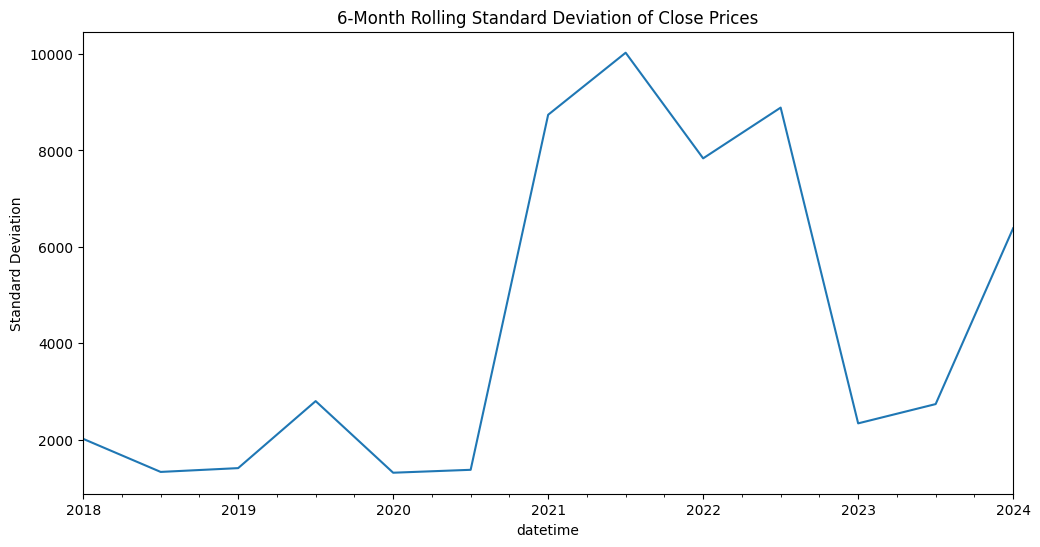

In [56]:
#plotting the standard deviation
std_6m.plot(figsize=(12,6))
plt.title('6-Month Rolling Standard Deviation of Close Prices')
plt.ylabel('Standard Deviation')
plt.show()